## Imports

In [1]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio import features
import numpy as np
import matplotlib.pyplot as plt
from pystac_client import Client
from odc.stac import load
import os
from shapely import geometry
from shapely.geometry import box
from sklearn.model_selection import train_test_split
import seaborn as sns

In [5]:
import ee
import geemap

ee.Authenticate(force=True, auth_mode='localhost')


Successfully saved authorization token.


In [7]:
project_id = "ee-abdullahr-solar"
ee.Initialize(project=project_id)

## Dataset Preparation

In [3]:
gpkg_path = "global_pv_facility_inventory.gpkg" 
solar_gdf = gpd.read_file(gpkg_path)


🌍 GLOBAL SOLAR DATASET (>=2019, >=100m²)
Total Sites Remaining: 63,939
Total Area Covered:    9,837.85 km²
Most Represented:      China



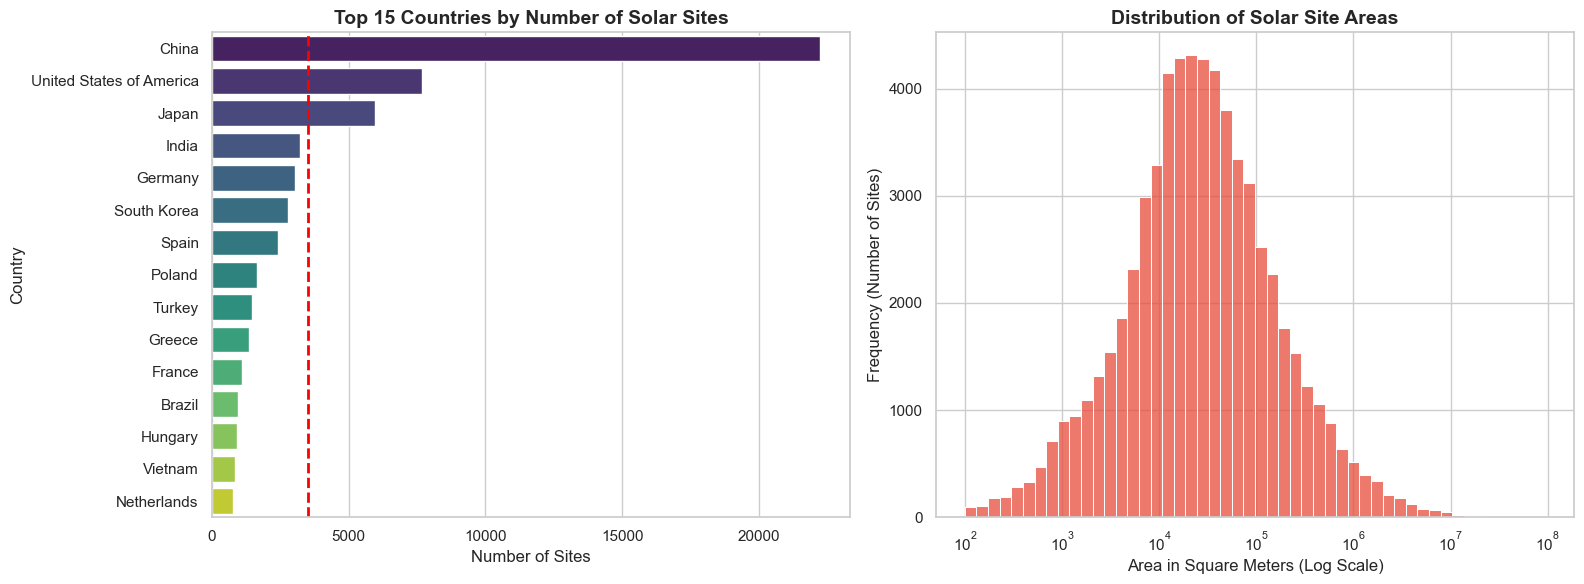

In [52]:
# ==============================================================================
# 1. APPLY FILTERS
# ==============================================================================
# Since 'year' is already an int64 and 'area_m2' is already calculated, 
# we can filter the entire dataset in two extremely fast, simple lines.

filtered_gdf = solar_gdf[
    (solar_gdf['year'] >= 2019) & 
    (solar_gdf['area_m2'] >= 100.0)
].copy()

# ==============================================================================
# 2. GENERAL STATISTICS
# ==============================================================================
total_sites = len(filtered_gdf)
total_area_km2 = filtered_gdf['area_m2'].sum() / 1e6 # Convert m^2 to km^2
top_country = filtered_gdf['country'].value_counts().idxmax() 

print("\n" + "="*40)
print("🌍 GLOBAL SOLAR DATASET (>=2019, >=100m²)")
print("="*40)
print(f"Total Sites Remaining: {total_sites:,}")
print(f"Total Area Covered:    {total_area_km2:,.2f} km²")
print(f"Most Represented:      {top_country}")
print("="*40 + "\n")

# ==============================================================================
# 3. VISUALIZATIONS
# ==============================================================================
# Set a clean visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot A: Top 15 Countries ---
top_countries = filtered_gdf['country'].value_counts().head(15)
sns.barplot(
    x=top_countries.values, 
    y=top_countries.index, 
    ax=axes[0], 
    palette="viridis",
    hue=top_countries.index, # Added hue to avoid seaborn warnings
    legend=False
)

axes[0].axvline(3500, color='red', linestyle='dashed', linewidth=2)
axes[0].set_title("Top 15 Countries by Number of Solar Sites", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Number of Sites", fontsize=12)
axes[0].set_ylabel("Country", fontsize=12)

# --- Plot B: Area Distribution ---
# Using a log scale because solar site areas have a massive right-skew
# (lots of small 100m^2 sites, a few massive 10,000,000m^2 utility farms)
sns.histplot(
    data=filtered_gdf, 
    x='area_m2', 
    bins=50, 
    log_scale=True, 
    ax=axes[1], 
    color="#e74c3c"
)

axes[1].set_title("Distribution of Solar Site Areas", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Area in Square Meters (Log Scale)", fontsize=12)
axes[1].set_ylabel("Frequency (Number of Sites)", fontsize=12)

plt.tight_layout()
plt.show()

In [5]:
# Assuming your filtered_gdf is what we are using for the ML pipeline
train_gdf = filtered_gdf.copy()

# 1. The Resume Flag: Tracks if the image chip was successfully downloaded
train_gdf['exported'] = False

# 2. The Linker: Stores the exact file path (e.g., "chip_140945_2023.npy") 
# so the PyTorch Dataset class knows exactly what to load
train_gdf['export_filename'] = None

# 3. The Temporal Target: Maps to the 'year' column so we know which 
# historical satellite mosaic to pull.
train_gdf['target_year'] = train_gdf['year']

# 4. The Footprint: Initialized as None for now. 
# Tomorrow, we will calculate the 128x128 pixel Shapely Polygons and store them here!
train_gdf['ml_bbox'] = None

train_gdf['dataset_split'] = 'unassigned'  # 'train', 'val', or 'test'

# Let's verify the new pipeline schema
print("Training Pipeline Schema Ready:")
print(train_gdf[['PV_ID', 'target_year', 'exported', 'export_filename', 'ml_bbox']].head())

Training Pipeline Schema Ready:
   PV_ID  target_year  exported export_filename ml_bbox
0      1         2020     False            None    None
2      3         2021     False            None    None
3      4         2023     False            None    None
4      5         2024     False            None    None
5      6         2022     False            None    None


In [11]:
print(f"Starting total sites: {len(train_gdf):,}")

# 1. Shuffle the entire dataset to ensure random sampling within countries
# (random_state=42 ensures you get the exact same split if you run this twice)
shuffled_gdf = train_gdf.sample(frac=1, random_state=42).reset_index(drop=True)

# 2. Group by country and take up to 3500 random sites from each
CAP = 3500
base_train_gdf = shuffled_gdf.groupby('country').head(CAP).copy()

# 3. Create the overflow dataset containing everything left over
# We identify the leftovers by dropping the indices that were used in the base dataset
overflow_gdf = shuffled_gdf.drop(base_train_gdf.index).copy()

# ==============================================================================
# VERIFICATION
# ==============================================================================
print("\n" + "="*40)
print("🌍 DATASET SPLIT RESULTS")
print("="*40)
print(f"Base Training Dataset: {len(base_train_gdf):,} sites")
print(f"Overflow Dataset:      {len(overflow_gdf):,} sites")
print("="*40 + "\n")

# Let's look at what happened to the top 5 countries
print("Top 5 Countries in Base Dataset:")
print(base_train_gdf['country'].value_counts().head(10))

print("\nTop 5 Countries in Overflow Dataset:")
print(overflow_gdf['country'].value_counts().head(5))

Starting total sites: 63,939

🌍 DATASET SPLIT RESULTS
Base Training Dataset: 38,599 sites
Overflow Dataset:      25,340 sites

Top 5 Countries in Base Dataset:
country
China                       3500
Japan                       3500
United States of America    3500
India                       3232
Germany                     3023
South Korea                 2789
Spain                       2402
Poland                      1661
Turkey                      1481
Greece                      1349
Name: count, dtype: int64

Top 5 Countries in Overflow Dataset:
country
China                       18719
United States of America     4168
Japan                        2453
Name: count, dtype: int64


In [23]:
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from tqdm import tqdm

# ==============================================================================
# 1. SETUP THE EXCLUSION ZONE
# ==============================================================================
print("Building the Global Solar Exclusion Zone...")
# We use the FULL dataset (solar_gdf) to ensure we avoid ALL known sites, 
# not just the ones in our training split.
solar_gdf_meters = solar_gdf.to_crs("EPSG:6933")

# Buffer every known site by 3,000 meters (approx 300 pixels) to be totally safe
# unary_union merges them all into one massive global "Do Not Touch" multipolygon
exclusion_zone = solar_gdf_meters.geometry.buffer(5000).unary_union

# 2. LOAD WORLD BOUNDARIES (Direct from Web)
print("Fetching world map boundaries...")
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"
world = gpd.read_file(url)
world = world.to_crs("EPSG:6933")

# Note: The 'name' column in this GeoJSON is called 'name', 
# so the rest of the script (world.name == country_name) will still work perfectly!

# ==============================================================================
# 3. GENERATE PROPORTIONAL NEGATIVE CHIPS (512x512)
# ==============================================================================
# Get our target 1:1 ratio from the base training set
target_counts = base_train_gdf['country'].value_counts()

negative_records = []
# 512 pixels * 10m/pixel = 5120 meters. Radius from center is 2560m.
HALF_BOX_METERS = 2560 

print(f"Generating True Negative 512x512 Bounding Boxes...")
for country_name, required_count in tqdm(target_counts.items()):
    
    # Try to find the country in the world map
    # (Note: Name matching can sometimes be tricky between datasets, e.g., 'USA' vs 'United States')
    country_match = world[world.name == country_name]
    
    if country_match.empty:
        # Fallback: If names don't match, just use the bounding box of the solar sites in that country
        country_geom = solar_gdf_meters[solar_gdf_meters['country'] == country_name].geometry.unary_union.convex_hull
    else:
        country_geom = country_match.geometry.unary_union
        
    # Find bounding box of the country to optimize random point generation
    minx, miny, maxx, maxy = country_geom.bounds
    
    valid_points_found = 0
    attempts = 0
    max_attempts = required_count * 50 # Prevent infinite loops in tiny countries
    
    while valid_points_found < required_count and attempts < max_attempts:
        attempts += 1
        
        # 1. Generate a random point within the country's bounds
        random_x = np.random.uniform(minx, maxx)
        random_y = np.random.uniform(miny, maxy)
        random_point = Point(random_x, random_y)
        
        # 2. Check if it's actually inside the country borders AND NOT in the exclusion zone
        if country_geom.contains(random_point) and not exclusion_zone.contains(random_point):
            
            # 3. Build the 5120m x 5120m bounding box around the point
            neg_bbox = box(
                random_x - HALF_BOX_METERS, 
                random_y - HALF_BOX_METERS, 
                random_x + HALF_BOX_METERS, 
                random_y + HALF_BOX_METERS
            )
            
            negative_records.append({
                'PV_ID': f"NEG_{country_name[:3].upper()}_{valid_points_found}",
                'country': country_name,
                'target_year': 2023, # You can randomize this later if needed
                'exported': False,
                'export_filename': None,
                'dataset_split': 'unassigned',
                'geometry': neg_bbox # We store the BOX, not the point!
            })
            valid_points_found += 1

# ==============================================================================
# 4. FINALIZE THE NEGATIVE GEODATAFRAME
# ==============================================================================
negative_gdf = gpd.GeoDataFrame(negative_records, crs="EPSG:6933")

# Project back to standard GPS coordinates for the API
negative_gdf = negative_gdf.to_crs("EPSG:4326")

print("\n" + "="*40)
print("✅ TRUE NEGATIVE DATASET GENERATED")
print("="*40)
print(f"Total Negative 512x512 Chips: {len(negative_gdf):,}")
print("="*40 + "\n")

Building the Global Solar Exclusion Zone...


/tmp/ipykernel_64486/2077122079.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  exclusion_zone = solar_gdf_meters.geometry.buffer(5000).unary_union


Fetching world map boundaries...
Generating True Negative 512x512 Bounding Boxes...


0it [00:00, ?it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
1it [00:00,  3.40it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
2it [00:00,  2.10it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
3it [00:01,  2.42it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  country_geom = country_match.geometry.unary_union
4it [00:01,  2.82it/s]/tmp/ipykernel_64486/2077122079.py:49: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' me


✅ TRUE NEGATIVE DATASET GENERATED
Total Negative 512x512 Chips: 38,564



/tmp/ipykernel_64486/1072795844.py:29: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  exclusion_patch = mpatches.Patch(


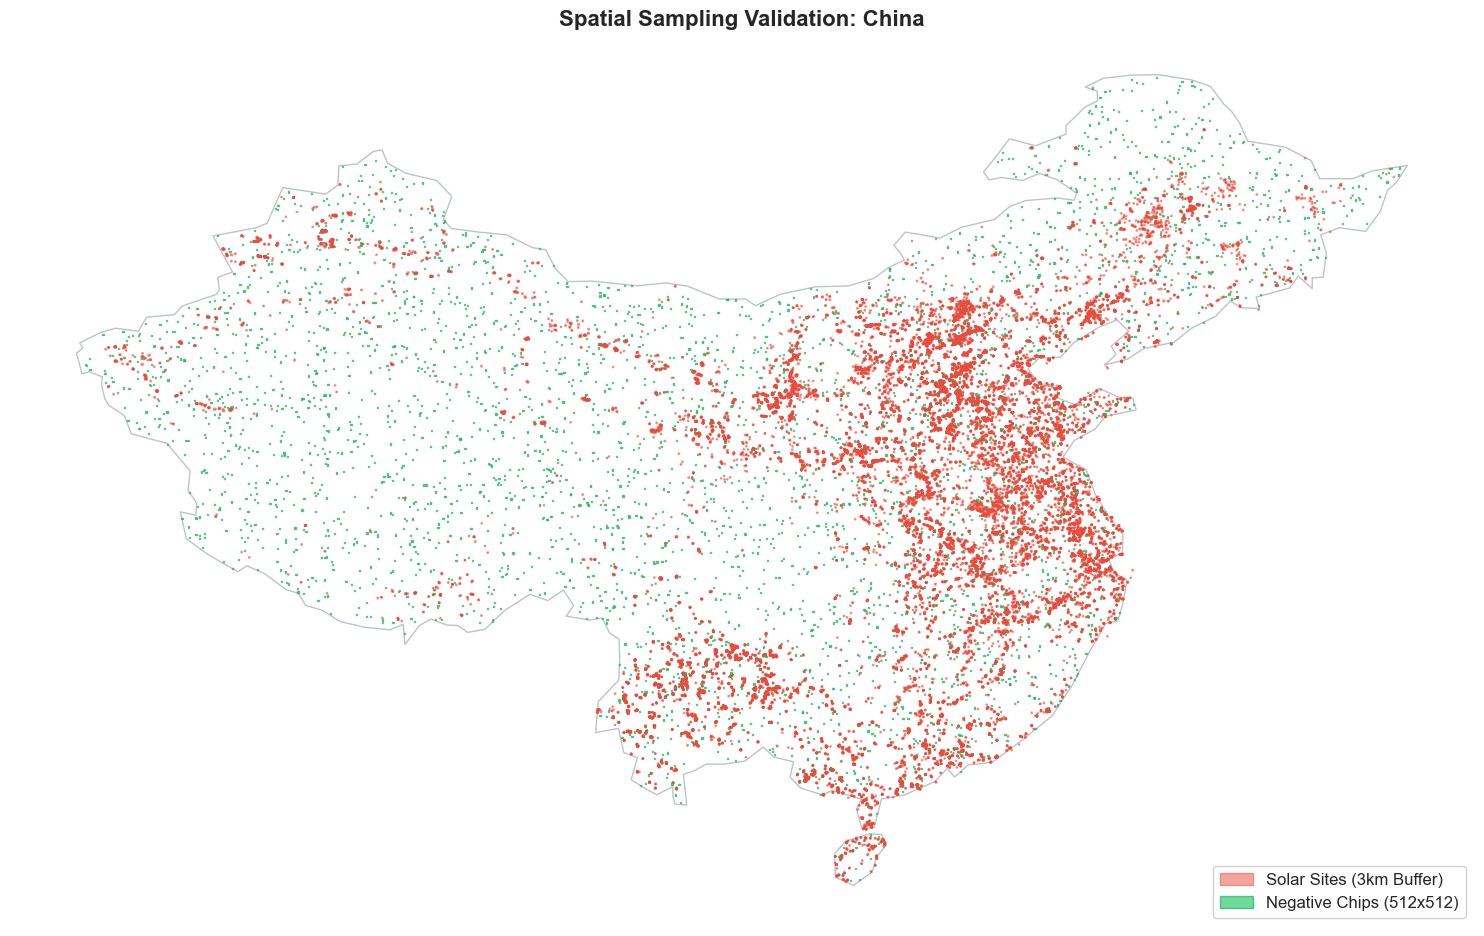

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd

# 1. Filter for the target country
target_country = "China"
country_boundary = world[world.name == target_country].to_crs("EPSG:6933")

# 2. Get Solar Sites in China + Buffer them by 3000m
china_solar = solar_gdf[solar_gdf['country'] == target_country].to_crs("EPSG:6933")
china_exclusion_zones = china_solar.geometry.buffer(3000)

# 3. Get our new Negative Bounding Boxes for China
china_negatives = negative_gdf[negative_gdf['country'] == target_country].to_crs("EPSG:6933")

# 4. Plotting
fig, ax = plt.subplots(figsize=(15, 12))

# Plot Country Background
country_boundary.plot(ax=ax, color='none', edgecolor='#bdc3c7', linewidth=1)

# Plot the Geometries (no need for label= here)
china_exclusion_zones.plot(ax=ax, color='#e74c3c', alpha=0.5, edgecolor='#e74c3c')
china_negatives.plot(ax=ax, color='#2ecc71', alpha=0.7, edgecolor='#27ae60')

# =========================================================
# THE FIX: Custom Legend Handles
# =========================================================
exclusion_patch = mpatches.Patch(
    color='#e74c3c', edgecolor='#e74c3c', alpha=0.5, 
    label='Solar Sites (3km Buffer)'
)
negative_patch = mpatches.Patch(
    facecolor='#2ecc71', edgecolor='#27ae60', alpha=0.7, 
    label='Negative Chips (512x512)'
)

ax.set_title(f"Spatial Sampling Validation: {target_country}", fontsize=16, fontweight='bold')
ax.legend(handles=[exclusion_patch, negative_patch], loc='lower right', framealpha=0.9, fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.show()

In [49]:
import numpy as np

print("Finalizing True Negative Dataset...")

# Work on a copy to avoid Pandas warnings
df_neg = negative_gdf.copy()

# ==============================================================================
# 1. RANDOMIZED TEMPORAL LOGIC
# ==============================================================================
# np.random.randint is exclusive on the high end, so 2023 gives us 2017-2022
df_neg['target_year'] = np.random.randint(2017, 2023, size=len(df_neg))

# ==============================================================================
# 2. NAMING CONVENTION
# ==============================================================================
df_neg['export_filename'] = (
    df_neg['PV_ID'].astype(str) + "_" + 
    df_neg['target_year'].astype(str) + ".tif"
)

# ==============================================================================
# 3. AREA & GEOGRAPHIC METADATA
# ==============================================================================
# No solar panels here!
df_neg['area_m2'] = 0.0

# Ensure we are in standard GPS coordinates before calculating centroids
df_neg = df_neg.to_crs("EPSG:4326")

# Calculate the exact center of the 512x512 box
centroids = df_neg.geometry.centroid
df_neg['latitude'] = centroids.y
df_neg['longitude'] = centroids.x

# ==============================================================================
# 4. SCHEMA ALIGNMENT (Crucial for the Export Script)
# ==============================================================================
# Your export script will be looking for a column named 'ml_bbox'. 
# Since the 'geometry' of the negative dataset IS the bounding box, 
# we simply copy it over so both dataframes have the exact same structure!
df_neg['ml_bbox'] = df_neg.geometry

# Save the finalized dataframe back to your main variable
negative_gdf = df_neg

# ==============================================================================
# VERIFICATION
# ==============================================================================
print("\n✅ NEGATIVE DATASET FINALIZED.")
print(f"Total Rows: {len(negative_gdf):,}")
print("\nSample Output:")
print(negative_gdf[['PV_ID', 'country', 'target_year', 'export_filename', 'latitude', 'longitude']].head())

Finalizing True Negative Dataset...

✅ NEGATIVE DATASET FINALIZED.
Total Rows: 38,564

Sample Output:
       PV_ID country  target_year     export_filename   latitude   longitude
0  NEG_CHI_0   China         2022  NEG_CHI_0_2022.tif  41.102360   96.743575
1  NEG_CHI_1   China         2019  NEG_CHI_1_2019.tif  23.412427  109.621379
2  NEG_CHI_2   China         2018  NEG_CHI_2_2018.tif  35.779735   91.880557
3  NEG_CHI_3   China         2017  NEG_CHI_3_2017.tif  36.260614  110.043062
4  NEG_CHI_4   China         2018  NEG_CHI_4_2018.tif  50.901524  122.076791


/tmp/ipykernel_64486/3260320207.py:32: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df_neg.geometry.centroid


In [26]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd

def finalize_pipeline_dataset(gdf):
    """Applies target year, export filename, and dynamic ml_bbox generation."""
    # Work on a copy to avoid Pandas warnings
    df = gdf.copy()
    
    # ==============================================================================
    # 1. TEMPORAL LOGIC (Target Year)
    # ==============================================================================
    # Subtract 2 years to get pre-construction imagery
    df['target_year'] = df['year'] - 2
    
    # Sanity Check: Floor it at 2017 (the start of the AlphaEarth archive)
    df['target_year'] = df['target_year'].clip(lower=2017)
    
    # ==============================================================================
    # 2. NAMING CONVENTION (Export Filename)
    # ==============================================================================
    # Replace spaces in country names with underscores so file paths don't break
    clean_country = df['country'].str.replace(' ', '_')
    
    df['export_filename'] = (
        df['PV_ID'].astype(str) + "_" + 
        clean_country + "_" + 
        df['target_year'].astype(str) + ".tif"
    )
    
    # ==============================================================================
    # 3. SPATIAL LOGIC (ml_bbox)
    # ==============================================================================
    # Project to a metric Equal-Area CRS (EPSG:6933) to do perfect 3000m math
    gdf_meters = df.to_crs("EPSG:6933")
    
    # Extract the strict bounding box limits for every solar site
    # This returns a dataframe with columns: minx, miny, maxx, maxy
    bounds = gdf_meters.geometry.bounds
    
    # Expand the bounds by 3000 meters in all cardinal directions
    # A 100m site becomes 6100m. A 500m site becomes 6500m.
    expanded_boxes = bounds.apply(
        lambda row: box(row['minx'] - 3000, 
                        row['miny'] - 3000, 
                        row['maxx'] + 3000, 
                        row['maxy'] + 3000), 
        axis=1
    )
    
    # Convert those new boxes back into a GeoSeries
    expanded_gdf = gpd.GeoDataFrame(geometry=expanded_boxes, crs="EPSG:6933")
    
    # Project back to standard GPS coordinates (EPSG:4326) for the Earth Engine API
    df['ml_bbox'] = expanded_gdf.to_crs("EPSG:4326").geometry
    
    return df

# ==============================================================================
# EXECUTION
# ==============================================================================
print("Finalizing Base Training Dataset...")
base_train_gdf = finalize_pipeline_dataset(base_train_gdf)

print("Finalizing Overflow Dataset...")
overflow_gdf = finalize_pipeline_dataset(overflow_gdf)

print("\n" + "="*50)
print("✅ PREPROCESSING COMPLETE. READY FOR DOWNLOAD.")
print("="*50)

# Print a sample to verify everything looks right
print("\nSample Output (Base Train):")
print(base_train_gdf[['PV_ID', 'year', 'target_year', 'export_filename', 'ml_bbox']].head(3))

Finalizing Base Training Dataset...
Finalizing Overflow Dataset...

✅ PREPROCESSING COMPLETE. READY FOR DOWNLOAD.

Sample Output (Base Train):
   PV_ID  year  target_year       export_filename  \
0  41621  2023         2021  41621_China_2021.tif   
1  36931  2019         2017  36931_China_2017.tif   
2  15628  2020         2018  15628_Japan_2018.tif   

                                             ml_bbox  
0  POLYGON ((116.82672 36.7867, 116.82672 36.8470...  
1  POLYGON ((115.27506 40.46989, 115.27506 40.533...  
2  POLYGON ((131.29424 31.85473, 131.29424 31.910...  


In [33]:
import geopandas as gpd
from shapely.geometry import box
import pandas as pd
import numpy as np

def finalize_pipeline_dataset(gdf):
    """Applies target year, export filename, and dynamic ml_bbox generation."""
    df = gdf.copy()
    
    # ==============================================================================
    # 1. TEMPORAL & NAMING LOGIC
    # ==============================================================================
    df['target_year'] = df['year'] - 2
    df['target_year'] = df['target_year'].clip(lower=2017)
    
    clean_country = df['country'].str.replace(' ', '_')
    df['export_filename'] = (
        df['PV_ID'].astype(str) + "_" + 
        clean_country + "_" + 
        df['target_year'].astype(str) + ".tif"
    )
    
    # ==============================================================================
    # 2. SPATIAL LOGIC (The Geographic Math Fix)
    # ==============================================================================
    # We work strictly in Lat/Lon (EPSG:4326) to ensure the box is never tilted.
    bounds = df.geometry.bounds
    
    # 1 degree of latitude is ~111.32 km anywhere on Earth
    LAT_DEG_IN_METERS = 111320.0
    lat_pad = 3000.0 / LAT_DEG_IN_METERS
    
    # Calculate the center latitude for each site to dynamically scale longitude
    center_lats = np.radians((bounds['miny'] + bounds['maxy']) / 2.0)
    lon_pad = 3000.0 / (LAT_DEG_IN_METERS * np.cos(center_lats))
    
    # Vectorized bounding box generation
    expanded_boxes = [
        box(minx - lon, miny - lat_pad, maxx + lon, maxy + lat_pad)
        for minx, miny, maxx, maxy, lon in zip(
            bounds['minx'], bounds['miny'], bounds['maxx'], bounds['maxy'], lon_pad
        )
    ]
    
    # Save perfectly un-tilted, distance-accurate Lat/Lon boxes!
    df['ml_bbox'] = gpd.GeoSeries(expanded_boxes, index=df.index, crs="EPSG:4326")
    
    return df

# ==============================================================================
# EXECUTE THE FIX
# ==============================================================================
print("Re-calculating Base Training Dataset with Trigonometric Padding...")
base_train_gdf = finalize_pipeline_dataset(base_train_gdf)

print("Re-calculating Overflow Dataset...")
overflow_gdf = finalize_pipeline_dataset(overflow_gdf)

print("✅ FIXED AND READY!")

Re-calculating Base Training Dataset with Trigonometric Padding...
Re-calculating Overflow Dataset...
✅ FIXED AND READY!


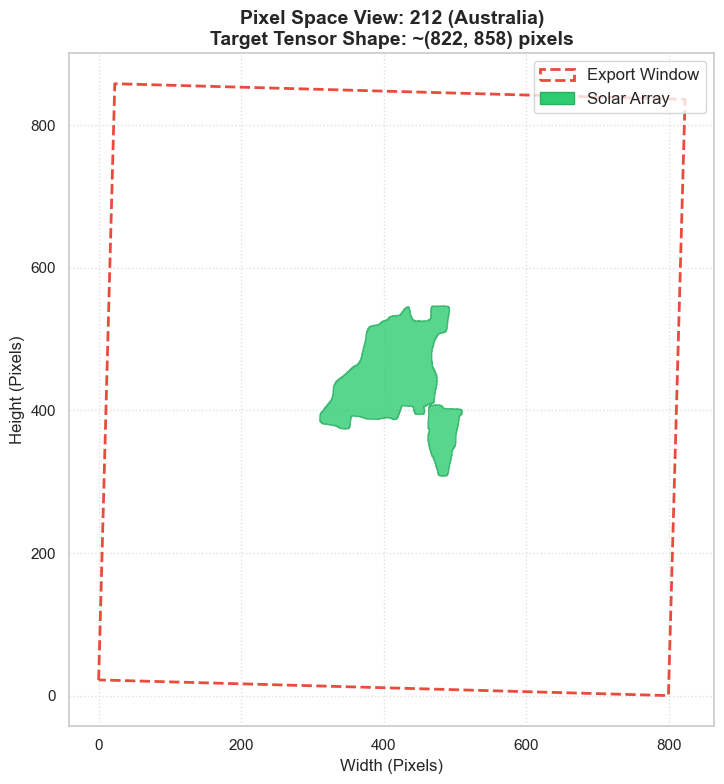

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import geopandas as gpd
from shapely.affinity import translate, scale

# ==============================================================================
# 1. SELECT A RANDOM SITE
# ==============================================================================
random_site = base_train_gdf.sample(1).iloc[0]

site_id = random_site['PV_ID']
country = random_site['country']
target_year = random_site['target_year']

# Convert to GeoSeries (raw lat/lon)
solar_latlon = gpd.GeoSeries([random_site['geometry']], crs="EPSG:4326")
box_latlon = gpd.GeoSeries([random_site['ml_bbox']], crs="EPSG:4326")

# ==============================================================================
# 2. EXTRACT AND PROJECT GEOMETRIES (THE UTM FIX)
# ==============================================================================
# Automatically calculate the perfect, distortion-free Local UTM zone
local_utm_crs = solar_latlon.estimate_utm_crs()

# Project to the local metric zone
solar_meters = solar_latlon.to_crs(local_utm_crs)
box_meters = box_latlon.to_crs(local_utm_crs)

# ==============================================================================
# 3. CONVERT TO PIXEL SPACE (10m = 1 Pixel, Start at 0,0)
# ==============================================================================
PIXEL_RES = 10.0

# Find the bottom-left corner of our ml_bbox in meters
minx, miny, maxx, maxy = box_meters.geometry.iloc[0].bounds

def convert_to_pixels(geom):
    # Shift the bottom-left corner to (0, 0)
    shifted = translate(geom, xoff=-minx, yoff=-miny)
    # Divide by 10 to convert meters to pixels
    pixel_geom = scale(shifted, xfact=1/PIXEL_RES, yfact=1/PIXEL_RES, origin=(0,0))
    return pixel_geom

# Apply the math to get our final pixel geometries
solar_pixels = solar_meters.apply(convert_to_pixels)
box_pixels = box_meters.apply(convert_to_pixels)

# ==============================================================================
# 4. VISUALIZE IN PIXEL SPACE
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the ML Bounding Box
box_pixels.plot(
    ax=ax, facecolor='none', edgecolor='#e74c3c', 
    linewidth=2, linestyle='--'
)

# Plot the Solar Array
solar_pixels.plot(
    ax=ax, facecolor='#2ecc71', edgecolor='#27ae60', alpha=0.8
)

# Formatting (dynamically grab the max width/height of the new pixel box)
max_w = int(box_pixels.geometry.iloc[0].bounds[2])
max_h = int(box_pixels.geometry.iloc[0].bounds[3])

ax.set_title(
    f"Pixel Space View: {site_id} ({country})\n"
    f"Target Tensor Shape: ~({max_w}, {max_h}) pixels", 
    fontsize=14, fontweight='bold'
)

box_patch = mpatches.Patch(facecolor='none', edgecolor='#e74c3c', linewidth=2, linestyle='--', label='Export Window')
solar_patch = mpatches.Patch(facecolor='#2ecc71', edgecolor='#27ae60', label='Solar Array')
ax.legend(handles=[box_patch, solar_patch], loc='upper right', fontsize=12)

ax.set_xlabel("Width (Pixels)", fontsize=12)
ax.set_ylabel("Height (Pixels)", fontsize=12)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

In [51]:
import os

# Define your master file name
output_file = "global_solar_ml_pipeline.gpkg"
print(f"Saving datasets to {output_file}...")

def prep_for_gpkg(gdf):
    """Converts secondary geometries to text strings for safe saving."""
    df = gdf.copy()
    # Convert the bounding box geometry into a Well-Known Text (WKT) string
    if 'ml_bbox' in df.columns:
        df['ml_bbox'] = df['ml_bbox'].to_wkt()
    return df

# 1. Save the Base Training Set
prep_for_gpkg(base_train_gdf).to_file(
    output_file, 
    layer="base_train", 
    driver="GPKG"
)
print("✅ Saved base_train layer")

# 2. Save the Overflow Set
prep_for_gpkg(overflow_gdf).to_file(
    output_file, 
    layer="overflow", 
    driver="GPKG"
)
print("✅ Saved overflow layer")

# 3. Save the Negative Set
prep_for_gpkg(negative_gdf).to_file(
    output_file, 
    layer="negative", 
    driver="GPKG"
)
print("✅ Saved negative layer")

print("\nAll datasets successfully packed into a single GeoPackage!")

Saving datasets to global_solar_ml_pipeline.gpkg...
✅ Saved base_train layer
✅ Saved overflow layer
✅ Saved negative layer

All datasets successfully packed into a single GeoPackage!


## Dataset Loading

In [8]:
# Define the file path
gpkg_file = "global_solar_ml_pipeline.gpkg"

print("Loading datasets from GeoPackage...")

# 1. Load the layers
base_train_gdf = gpd.read_file(gpkg_file, layer="base_train")
overflow_gdf = gpd.read_file(gpkg_file, layer="overflow")
negative_gdf = gpd.read_file(gpkg_file, layer="negative")

# 2. Convert the ml_bbox text strings back into active Polygon geometries
base_train_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(base_train_gdf['ml_bbox'])
overflow_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(overflow_gdf['ml_bbox'])
negative_gdf['ml_bbox'] = gpd.GeoSeries.from_wkt(negative_gdf['ml_bbox'])

# 3. Print the summaries
print("\n" + "="*35)
print("📊 DATASET COUNTS")
print("="*35)
print(f"Base Train: {len(base_train_gdf):,} sites")
print(f"Overflow:   {len(overflow_gdf):,} sites")
print(f"Negative:   {len(negative_gdf):,} sites")
print("-" * 30)
print(f"Total:      {len(base_train_gdf) + len(overflow_gdf) + len(negative_gdf):,} sites")

print("\n" + "="*35)
print("📋 TRAINING DATA COLUMN STRUCTURE")
print("="*35)
print(base_train_gdf.dtypes)

Loading datasets from GeoPackage...

📊 DATASET COUNTS
Base Train: 38,599 sites
Overflow:   25,340 sites
Negative:   38,564 sites
------------------------------
Total:      102,503 sites

📋 TRAINING DATA COLUMN STRUCTURE
PV_ID                 int64
latitude            float64
longitude           float64
country                 str
year                  int64
area_m2             float64
exported               bool
export_filename         str
target_year           int64
ml_bbox            geometry
dataset_split           str
geometry           geometry
dtype: object
